<a href="https://colab.research.google.com/github/giolanta-nta/Homework/blob/main/%CE%95%CE%B9%CF%83%CE%B1%CE%B3%CF%89%CE%B3%CE%B7%CC%81_%CF%83%CF%84%CE%B1_pandas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Εισαγωγή στα pandas

Σήμερα θα μάθουμε να εισάγουμε, επεξεργαζόμαστε και αποθηκεύουμε πλαίσια δεδομένων, που από εδώ και στο εξής θα τα αποκαλούμε Dataframes και για συντομία df.

Για αρχή πρέπει να καλέσουμε τη βιβλιοθήκη pandas για να μπορέσουμε να δουλέψουμε με Dataframes.

Ξεκινάμε λοιπόν εισάγωντας ένα αρχείο comma-separated values (CSV).



In [1]:
import pandas as pd


In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/datajour-gr/Data_journalism/refs/heads/master/week3/countries.csv")

Ποιες χωρες σε κάθε ηπειρο ειναι πανω απο τον μεσο ορο της ηπειρου που ανηκουν; 1 df

In [15]:
df_Europe= df[df['continent'] == 'Europe']

In [16]:
df_Europe

,country,continent,gdp_per_capita,life_expectancy,population
1,Albania,Europe,4195,74.200000,3071856
6,Armenia,Europe,2114,71.494000,3076098
8,Austria,Europe,32008,78.330000,8004712
9,Azerbaijan,Europe,2533,66.851000,8110723
14,Belarus,Europe,5936,68.990000,10057810
15,Belgium,Europe,29940,77.910000,10175684
20,Bosnia and Herzegovina,Europe,5733,74.882000,3693698
24,Bulgaria,Europe,6907,71.590000,8006158
41,Croatia,Europe,10582,74.798000,4505533
43,Cyprus,Europe,22821,78.011000,943294


In [17]:
df_Europe. sort_values(by='gdp_per_capita', ascending=False)

,country,continent,gdp_per_capita,life_expectancy,population
99,Luxembourg,Europe,63924,77.820000,435491
125,Norway,Europe,43174,78.760000,4490859
161,Switzerland,Europe,34386,79.990000,7167908
120,Netherlands,Europe,33000,78.240000,15862825
8,Austria,Europe,32008,78.330000,8004712
45,Denmark,Europe,31805,76.900000,5339501
74,Iceland,Europe,31092,79.720000,281210
79,Ireland,Europe,30827,76.660000,3803780
15,Belgium,Europe,29940,77.910000,10175684
61,Germany,Europe,29726,78.141275,82349027


Ποιες χώρες της Ευρρώπης έχουν GDP μεγαλύτερο από τον μέσο όρο GDP στην Ευρώπη;

In [18]:
df_Europe[df_Europe['gdp_per_capita'] > df_Europe['gdp_per_capita'].mean()].sort_values(by='gdp_per_capita', ascending=False)

,country,continent,gdp_per_capita,life_expectancy,population
99,Luxembourg,Europe,63924,77.820000,435491
125,Norway,Europe,43174,78.760000,4490859
161,Switzerland,Europe,34386,79.990000,7167908
120,Netherlands,Europe,33000,78.240000,15862825
8,Austria,Europe,32008,78.330000,8004712
45,Denmark,Europe,31805,76.900000,5339501
74,Iceland,Europe,31092,79.720000,281210
79,Ireland,Europe,30827,76.660000,3803780
15,Belgium,Europe,29940,77.910000,10175684
61,Germany,Europe,29726,78.141275,82349027


<Axes: xlabel='country', ylabel='gdp_per_capita'>

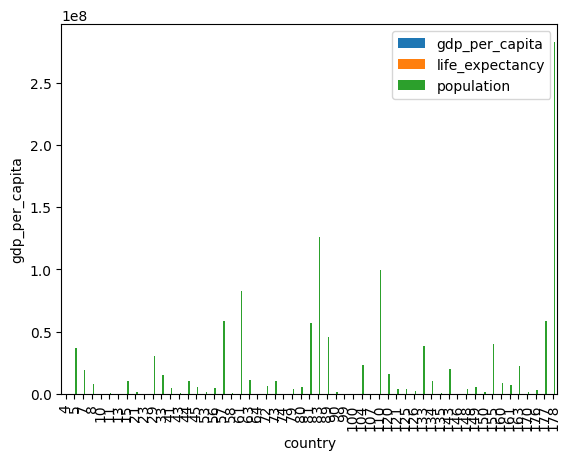

In [19]:
df[df['gdp_per_capita'] > df['gdp_per_capita'].mean()].plot(kind='bar', xlabel='country', ylabel='gdp_per_capita')

In [20]:
continent_mean= df.groupby('continent')['gdp_per_capita'].transform('mean').reset_index()
#transform: Συγκρίνω ανά γραμμή το ΑΕΠ της χώρας με τον μέσο όρο ΑΕΠ της ηπείρου
#reset_index(): Νέο df με τις καινούριες στήλες (τον μέσο όρο ΑΕΠ της ηπείρου εδώ)


In [26]:
#Λυση
continent_mean= df.groupby('continent')['gdp_per_capita'].transform('mean')

In [22]:
#Λυση
continent_mean

,gdp_per_capita
0,11106.437500
1,18647.880952
2,2621.648148
3,2621.648148
4,11665.681818
...,...
183,11106.437500
184,11106.437500
185,11106.437500
186,2621.648148


In [23]:
above_avg_count= df[df['gdp_per_capita'] > continent_mean]
#Συγκρίνω με τη νέα μεταβήτή που έχω δημιουργήσει (contintent_mean)

In [ ]:
above_avg_count

,country,continent,gdp_per_capita,life_expectancy,population
2,Algeria,Africa,5098,68.963,30533827
4,Antigua and Barbuda,N. America,12738,73.544,77656
5,Argentina,S. America,10571,73.822,36930709
7,Australia,Oceania,29241,79.930,19164351
8,Austria,Europe,32008,78.330,8004712
...,...,...,...,...,...
176,United Arab Emirates,Asia,30012,74.163,3033491
177,United Kingdom,Europe,28644,78.040,58874117
178,United States,N. America,39758,76.800,282496310
179,Uruguay,S. America,9092,74.777,3319066


In [25]:
continent_mean

,gdp_per_capita
0,11106.437500
1,18647.880952
2,2621.648148
3,2621.648148
4,11665.681818
...,...
183,11106.437500
184,11106.437500
185,11106.437500
186,2621.648148


In [32]:
gdp_continent_avg = df.groupby('continent')['gdp_per_capita'].mean()
display(gdp_continent_avg)

,gdp_per_capita
continent,
Africa,2621.648148
Asia,11106.437500
Europe,18647.880952
N. America,11665.681818
Oceania,8038.400000
S. America,6738.583333


Τώρα που έχουμε τον μέσο όρο ΑΕΠ για κάθε ήπειρο (`gdp_continent_avg`), μπορούμε να τον "χαρτογραφήσουμε" πίσω στη στήλη 'continent' του αρχικού DataFrame `df`. Έτσι, για κάθε χώρα, θα έχουμε τον μέσο όρο του ΑΕΠ της ηπείρου της. Στη συνέχεια, μπορούμε να φιλτράρουμε τις χώρες όπου το ΑΕΠ τους είναι μεγαλύτερο από τον μέσο όρο της ηπείρου τους.

In [50]:
countries_above_avg = df[df['gdp_per_capita'] > df['continent'].map(gdp_continent_avg)]
#display(countries_above_avg)
countries_above_avg.head()

,country,continent,gdp_per_capita,life_expectancy,population
2,Algeria,Africa,5098,68.963,30533827
4,Antigua and Barbuda,N. America,12738,73.544,77656
5,Argentina,S. America,10571,73.822,36930709
7,Australia,Oceania,29241,79.930,19164351
8,Austria,Europe,32008,78.330,8004712


In [ ]:
df[df['gdp_per_capita'] > df['gdp_per_capita'].mean()].sort_values(by='continent')

,country,continent,gdp_per_capita,life_expectancy,population
146,Seychelles,Africa,15230,71.771000,78685
58,Gabon,Africa,12764,59.744000,1235274
21,Botswana,Africa,10107,50.567000,1757925
72,"Hong Kong, China",Asia,29972,80.361000,6783317
143,Saudi Arabia,Asia,20001,72.401000,20045276
83,Japan,Asia,28559,81.350000,125720310
89,"Korea, Rep.",Asia,16995,76.114000,45987624
90,Kuwait,Asia,36397,73.133000,1940786
100,"Macao, China",Asia,22512,77.627000,431867
104,Malaysia,Asia,10161,72.810000,23414909


In [ ]:
df_Asia[df_Asia['gdp_per_capita'] > df_Asia['gdp_per_capita'].mean()]

,country,continent,gdp_per_capita,life_expectancy,population
11,Bahrain,Asia,22015,74.497,638193
23,Brunei,Asia,48020,75.927,327036
72,"Hong Kong, China",Asia,29972,80.361,6783317
80,Israel,Asia,22834,78.750,6014953
83,Japan,Asia,28559,81.350,125720310
89,"Korea, Rep.",Asia,16995,76.114,45987624
90,Kuwait,Asia,36397,73.133,1940786
100,"Macao, China",Asia,22512,77.627,431867
126,Oman,Asia,19204,72.139,2264163
135,Qatar,Asia,60394,76.680,590957


In [ ]:
df_continent = df.groupby('continent')

In [ ]:
df_continent


In [ ]:
sort_values(by='gdp_per_capita', ascending=False)

Γραφημα τη μεση τιμη των πιο πλουσιων κρατων ανα ηπειρο ή ο ααριθμος των πιο πλουσιων χωρων ανα ηπειρο

Με το .head( ) βλέπουμε τα πρώτα 5 κελιά και με το .tail( ) τα τελευταία. Μπορούμε να αλλάξουμε τον αριθμό των κελιών που εμφανίζονται
βάζοντας τον αριθμό που θέλουμε μέσα στις παρενθέσεις.

In [ ]:
df.head(30)

,country,continent,gdp_per_capita,life_expectancy,population
0,Afghanistan,Asia,663,54.863,22856302
1,Albania,Europe,4195,74.200,3071856
2,Algeria,Africa,5098,68.963,30533827
3,Angola,Africa,2446,45.234,13926373
4,Antigua and Barbuda,N. America,12738,73.544,77656
5,Argentina,S. America,10571,73.822,36930709
6,Armenia,Europe,2114,71.494,3076098
7,Australia,Oceania,29241,79.930,19164351
8,Austria,Europe,32008,78.330,8004712
9,Azerbaijan,Europe,2533,66.851,8110723


In [ ]:
df.head(8)

,country,continent,gdp_per_capita,life_expectancy,population
0,Afghanistan,Asia,663,54.863,22856302
1,Albania,Europe,4195,74.200,3071856
2,Algeria,Africa,5098,68.963,30533827
3,Angola,Africa,2446,45.234,13926373
4,Antigua and Barbuda,N. America,12738,73.544,77656
5,Argentina,S. America,10571,73.822,36930709
6,Armenia,Europe,2114,71.494,3076098
7,Australia,Oceania,29241,79.930,19164351


Η πρώτη στήλη στα αριστερά λέγεται index

In [ ]:
df.tail(10)

,country,continent,gdp_per_capita,life_expectancy,population
178,United States,N. America,39758,76.800,282496310
179,Uruguay,S. America,9092,74.777,3319066
180,Uzbekistan,Asia,1635,66.999,24775610
181,Vanuatu,Oceania,3762,67.438,185074
182,Venezuela,S. America,9434,72.432,24348304
183,Vietnam,Asia,1577,73.777,78758010
184,West Bank and Gaza,Asia,7586,70.929,3198560
185,"Yemen, Rep.",Asia,2217,60.404,17723186
186,Zambia,Africa,1035,41.802,10201562
187,Zimbabwe,Africa,745,43.976,12509477


Πάμε να δούμε τι στήλες έχουμε στα δεδομένα μας.

In [ ]:
df.columns

Index(['country', 'continent', 'gdp_per_capita', 'life_expectancy',
       'population'],
      dtype='object')

Ας δούμε τώρα και τι τύπος είναι η κάθε στήλη.

In [ ]:
df.dtypes
#object σημαίνει συμβολοσειρά

,0
country,object
continent,object
gdp_per_capita,int64
life_expectancy,float64
population,int64


Ας τα ταξινομήσουμε σύμφωνα με τον πληθυσμό κάθε χώρας.

In [ ]:
df.sort_values(by='population', ascending = False).head()

,country,continent,gdp_per_capita,life_expectancy,population
34,China,Asia,3407,72.124,1269116737
75,India,Asia,1648,62.129,1053898107
178,United States,N. America,39758,76.800,282496310
76,Indonesia,Asia,2714,67.289,213395411
22,Brazil,S. America,8056,70.261,174425387


In [ ]:
df["population"].head()

,population
0,22856302
1,3071856
2,30533827
3,13926373
4,77656


In [ ]:
df["population"].median()

6888970.5

In [ ]:
df['population'].mean()

np.float64(32526821.05319149)

In [ ]:
df["population"].sum()

np.int64(6115042358)

In [ ]:
df["population"].std()

123795162.37011255

In [ ]:
df["population"].max()

1269116737

Περιγραφή όλων των στηλών

In [ ]:
df["population"].describe()

,population
count,1.880000e+02
mean,3.252682e+07
std,1.237952e+08
min,5.619600e+04
25%,2.003170e+06
50%,6.888970e+06
75%,2.218517e+07
max,1.269117e+09


Δεν φαίνονται και τόσο ξεκάθαρα, ας τα δούμε σαν ακέραιους αριθμούς!

In [ ]:
df["population"].describe().astype(int)

,population
count,188
mean,32526821
std,123795162
min,56196
25%,2003169
50%,6888970
75%,22185170
max,1269116737


In [ ]:
df['continent'].value_counts().head()
#to value_counts metraei poses fores emfanizetai kati

,count
continent,
Africa,54
Asia,48
Europe,42
N. America,22
S. America,12


In [ ]:
df['continent'].describe()

,continent
count,188
unique,6
top,Africa
freq,54


In [ ]:
df.sort_values(by='life_expectancy', ascending=False).head(3)

,country,continent,gdp_per_capita,life_expectancy,population
83,Japan,Asia,28559,81.350,125720310
72,"Hong Kong, China",Asia,29972,80.361,6783317
161,Switzerland,Europe,34386,79.990,7167908


In [ ]:
df_Asia = df[df['continent']== 'Asia']

Πάμε να φτιάξουμε το πρώτο μας γράφημα!

In [ ]:
df['continent'].value_counts().plot

Κάτι προσπαθεί να κάνει, αλλά φαίνεται ότι κάτι λείπει...

Χρειαζόμαστε μια βιβλιοθήκη γραφικών.
Ας φέρουμε την matplotlib
Βάζοντας μπορστά το % αναθέτουμε την βιβλιοθήκη από δω και κάτω.

In [ ]:
%matplotlib inline

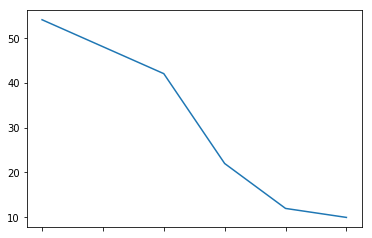

In [ ]:
df['continent'].value_counts().plot()

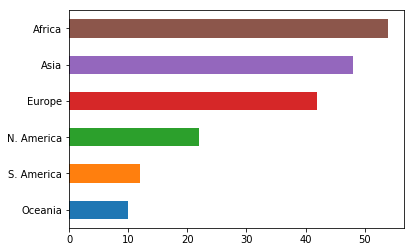

In [ ]:
df['continent'].value_counts().sort_values(ascending=True).plot(kind='barh')

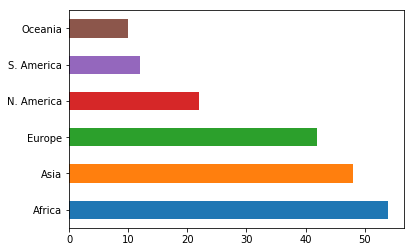

In [ ]:
df['continent'].value_counts().plot(kind='barh') #barh είναι το οριζόντιο γράφημα

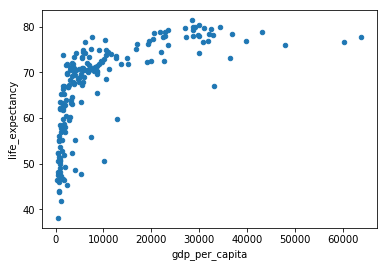

In [ ]:
df.plot(kind='scatter', x='gdp_per_capita', y='life_expectancy')

Ο τρόπος που αναλύουμε τα δεδομένα είναι ο εξής:
Πρώτα κάνουμε μια υπόθεση και μετά προχωρούμε ρωτώντας τα δεδομένα μας τις σχετικές ερωτήσεις. Δεν κάνουμε απλά αναζήτηση των δεδομένων!
Ας ρωτήσουμε πχ. ποια είναι η μεγαλύτερη χώρα, ποια έχει το μεγαλύτερο ΑΕΠ (Ακαθάριστο Εγχώριο Προϊόν (Gross domestic product - GDP)

Τι είναι ?
- Ακαθάριστο Εγχώριο Προϊόν είναι το σύνολο των προϊόντων, υλικών και άυλων, που παράχθηκαν μέσα στην επικράτεια μιας χώρας σε διάστημα ενός έτους, εκφρασμένο σε χρηματικές μονάδες, ακόμα και αν μέρος αυτού παράχθηκε από παραγωγικές μονάδες που ανήκουν σε κατοίκους του εξωτερικού.

## Πρέπει να βρούμε:

με ποια στήλη να κάνουμε το γκρουπάρισμα (group by)

από ποια στήλη θέλουμε πληροφορίες

τι είδους πληροφορίες θέλουμε από αυτή την στήλη

*Οι παρενθέσεις είναι για το groupby και οι αγκύλες για την στήλη από την οποία θέλουμε πληροφορίες, το groupby μπαίνει στην αρχή για να φιλτράρει

In [ ]:
df.groupby("continent")["gdp_per_capita"].mean()

continent
Africa         2621.648148
Asia          11106.437500
Europe        18647.880952
N. America    11665.681818
Oceania        8038.400000
S. America     6738.583333
Name: gdp_per_capita, dtype: float64

In [ ]:
df.groupby('continent')['country', 'population'].max()

,country,population
continent,,
Africa,Zimbabwe,123688536
Asia,"Yemen, Rep.",1269116737
Europe,United Kingdom,82349027
N. America,United States,282496310
Oceania,Vanuatu,19164351
S. America,Venezuela,174425387


In [ ]:
df.groupby('continent')['population'].max()

continent
Africa         123688536
Asia          1269116737
Europe          82349027
N. America     282496310
Oceania         19164351
S. America     174425387
Name: population, dtype: int64

In [ ]:
#Πόσες γραμμές και πόσες στήλες έχουμε
df.shape

(188, 5)

In [ ]:
df['new_continent'] = df['continent']

In [ ]:
df.continent.head()

0          Asia
1        Europe
2        Africa
3        Africa
4    N. America
Name: continent, dtype: object

In [ ]:
df.head()

,country,continent,gdp_per_capita,life_expectancy,population,new_continent
0,Afghanistan,Asia,663,54.863,22856302,Asia
1,Albania,Europe,4195,74.200,3071856,Europe
2,Algeria,Africa,5098,68.963,30533827,Africa
3,Angola,Africa,2446,45.234,13926373,Africa
4,Antigua and Barbuda,N. America,12738,73.544,77656,N. America


Ο τύπος boolean ορίζεται από το πεδίο τιμών {true, false}.

Οι παρακάτω τελεστές παράγουν αποτέλεσμα τύπου boolean:


In [ ]:
#=   Ισότητα
#<> Διάφορο
#<   Μικρότερο
#>   Μεγαλύτερο
#<= Μικρότερο ή ίσο
#>= Μεγαλύτερο ή ίσο

Πώς ρωτάμε το dataframe, είναι η ήπειρος σου η Ασία?

In [56]:
df_Asia = df[df['continent'] == 'Asia']

In [57]:
df_Asia.head()

,country,continent,gdp_per_capita,life_expectancy,population
0,Afghanistan,Asia,663,54.863,22856302
11,Bahrain,Asia,22015,74.497,638193
12,Bangladesh,Asia,1075,65.309,129592275
18,Bhutan,Asia,2922,60.307,571262
23,Brunei,Asia,48020,75.927,327036


Όταν δείτε απαντήσεις με *True False* τότε έχετε ξεχάσει να βάλετε αγκύλες!

In [ ]:
#df [ ] και μέσα το condition
df[df['continent'] == 'Asia']

,country,continent,gdp_per_capita,life_expectancy,population,new_continent
0,Afghanistan,Asia,663,54.863,22856302,Asia
11,Bahrain,Asia,22015,74.497,638193,Asia
12,Bangladesh,Asia,1075,65.309,129592275,Asia
18,Bhutan,Asia,2922,60.307,571262,Asia
23,Brunei,Asia,48020,75.927,327036,Asia
27,Cambodia,Asia,982,62.030,12446949,Asia
34,China,Asia,3407,72.124,1269116737,Asia
72,"Hong Kong, China",Asia,29972,80.361,6783317,Asia
75,India,Asia,1648,62.129,1053898107,Asia
76,Indonesia,Asia,2714,67.289,213395411,Asia


In [ ]:
df['gdp_per_capita'].mean()

9977.558510638299

Είναι το ΑΕΠ μεγαλύτερο από το μέσο όρο?
Θέλω όλα τα κελιά στα οποία είναι το ΑΕΠ μεγαλύτερο του μέσου όρου και τα θέλω σε μορφή dataframe

In [52]:
df[df['gdp_per_capita'] > df['gdp_per_capita'].mean()]

,country,continent,gdp_per_capita,life_expectancy,population
4,Antigua and Barbuda,N. America,12738,73.544000,77656
5,Argentina,S. America,10571,73.822000,36930709
7,Australia,Oceania,29241,79.930000,19164351
8,Austria,Europe,32008,78.330000,8004712
10,Bahamas,N. America,22728,72.370000,297651
11,Bahrain,Asia,22015,74.497000,638193
13,Barbados,N. America,14982,73.118000,267511
15,Belgium,Europe,29940,77.910000,10175684
21,Botswana,Africa,10107,50.567000,1757925
23,Brunei,Asia,48020,75.927000,327036


In [69]:
df_Asia.gdp_per_capita.mean()

np.float64(11106.4375)

gdp> mean in Asia
life expectancy max

In [ ]:
df_Asia[df['gdp_per_capita'] > df_Asia['gdp_per_capita'].mean()]

/tmp/ipykernel_1018/574230945.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_Asia[df['gdp_per_capita'] > df_Asia['gdp_per_capita'].mean()]


,country,continent,gdp_per_capita,life_expectancy,population
11,Bahrain,Asia,22015,74.497,638193
23,Brunei,Asia,48020,75.927,327036
72,"Hong Kong, China",Asia,29972,80.361,6783317
80,Israel,Asia,22834,78.750,6014953
83,Japan,Asia,28559,81.350,125720310
89,"Korea, Rep.",Asia,16995,76.114,45987624
90,Kuwait,Asia,36397,73.133,1940786
100,"Macao, China",Asia,22512,77.627,431867
126,Oman,Asia,19204,72.139,2264163
135,Qatar,Asia,60394,76.680,590957


In [ ]:
df_Asia.groupby('country')['life_expectancy'].max()

,life_expectancy
country,
Afghanistan,54.863
Bahrain,74.497
Bangladesh,65.309
Bhutan,60.307
Brunei,75.927
Cambodia,62.030
China,72.124
"Hong Kong, China",80.361
India,62.129


In [ ]:
df_Asia[df_Asia['gdp_per_capita'] > df_Asia['gdp_per_capita'].mean()].sort_values(by='life_expectancy', ascending=False).head(5)

,country,continent,gdp_per_capita,life_expectancy,population
83,Japan,Asia,28559,81.350,125720310
72,"Hong Kong, China",Asia,29972,80.361,6783317
80,Israel,Asia,22834,78.750,6014953
148,Singapore,Asia,36834,78.340,3919300
100,"Macao, China",Asia,22512,77.627,431867


In [62]:
gdp_Asia_mean = df_Asia['gdp_per_capita'].mean()

In [63]:
gdp_Asia_mean

np.float64(11106.4375)

In [68]:
df_Asia[df_Asia['gdp_per_capita'] > gdp_Asia_mean].sort_values(by='life_expectancy', ascending=False).head(5)

,country,continent,gdp_per_capita,life_expectancy,population
83,Japan,Asia,28559,81.350,125720310
72,"Hong Kong, China",Asia,29972,80.361,6783317
80,Israel,Asia,22834,78.750,6014953
148,Singapore,Asia,36834,78.340,3919300
100,"Macao, China",Asia,22512,77.627,431867


In [ ]:
df[(df['continent'] == 'Asia') & (df['gdp_per_capita'] > df['gdp_per_capita'].mean())].head()

,country,continent,gdp_per_capita,life_expectancy,population,new_continent
11,Bahrain,Asia,22015,74.497,638193,Asia
23,Brunei,Asia,48020,75.927,327036,Asia
72,"Hong Kong, China",Asia,29972,80.361,6783317,Asia
80,Israel,Asia,22834,78.750,6014953,Asia
83,Japan,Asia,28559,81.350,125720310,Asia


In [ ]:
df[(df['continent'] == 'Africa') & (df['life_expectancy'] < 40)]

,country,continent,gdp_per_capita,life_expectancy,population,new_continent,millions,aep
147,Sierra Leone,Africa,517,38.123,4143115,Africa,4.143115,2141990455


In [ ]:
# σε εκατομμύρια
df['population'] / 1000000

0       22.856302
1        3.071856
2       30.533827
3       13.926373
4        0.077656
5       36.930709
6        3.076098
7       19.164351
8        8.004712
9        8.110723
10       0.297651
11       0.638193
12     129.592275
13       0.267511
14      10.057810
15      10.175684
16       0.250512
17       6.517810
18       0.571262
19       8.307248
20       3.693698
21       1.757925
22     174.425387
23       0.327036
24       8.006158
25      12.294012
26       6.374347
27      12.446949
28      15.678269
29      30.667365
          ...    
158      0.466846
159      1.063832
160      8.860153
161      7.167908
162     15.988534
163     22.183000
164      6.172807
165     34.038161
166     63.155029
167      0.830089
168      4.793504
169      0.097935
170      1.292058
171      9.456117
172     63.627862
173      4.501419
174     24.213120
175     48.891792
176      3.033491
177     58.874117
178    282.496310
179      3.319066
180     24.775610
181      0.185074
182     24

Θέλουμε να σώσουμε το αποτέλεσμα σε ένα νέο dataframe και να είναι σε εκατομμύρια

In [ ]:
df['millions'] = df['population'] /1000000
df.head()

,country,continent,gdp_per_capita,life_expectancy,population,new_continent,millions
0,Afghanistan,Asia,663,54.863,22856302,Asia,22.856302
1,Albania,Europe,4195,74.200,3071856,Europe,3.071856
2,Algeria,Africa,5098,68.963,30533827,Africa,30.533827
3,Angola,Africa,2446,45.234,13926373,Africa,13.926373
4,Antigua and Barbuda,N. America,12738,73.544,77656,N. America,0.077656


Ας κάνουμε μια νέα στήλη με το ΑΕΠ, αλλά όχι κατά κεφαλήν

In [ ]:
df['aep'] = df['gdp_per_capita'] * df['population']
df.head()

,country,continent,gdp_per_capita,life_expectancy,population,new_continent,millions,aep
0,Afghanistan,Asia,663,54.863,22856302,Asia,22.856302,15153728226
1,Albania,Europe,4195,74.200,3071856,Europe,3.071856,12886435920
2,Algeria,Africa,5098,68.963,30533827,Africa,30.533827,155661450046
3,Angola,Africa,2446,45.234,13926373,Africa,13.926373,34063908358
4,Antigua and Barbuda,N. America,12738,73.544,77656,N. America,0.077656,989182128


'Οπως βλέπετε μπορούμε να εκτελέσουμε εντολές και χωρίς τα "" εκτός και αν έχουν κενά τα ονόματα των στηλών!

In [ ]:
df.gdp_per_capita * df.population

0         15153728226
1         12886435920
2        155661450046
3         34063908358
4           989182128
5        390394524839
6          6502871172
7        560384787591
8        256214821696
9         20544461359
10         6765011928
11        14049818895
12       139311695625
13         4007849802
14        59703160160
15       304659978960
16         1639601040
17         8518777670
18         1669227564
19        28194799712
20        21175970634
21        17767347975
22      1405170917672
23        15704268720
24        55298533306
25        12306306012
26         2823835721
27        12222903918
28        28267919007
29       995094659520
            ...      
158        2650284742
159        4277668472
160      253754781920
161      246475684488
162       62914881290
163      521855075000
164        6178979807
165       28115520986
166      352278751762
167        2276934127
168        4266218560
169         478510410
170       13561440768
171       51819521160
172      4

In [ ]:
df_new2 = df[['continent', 'population', 'aep']]

In [ ]:
df_new2.head()

,continent,population,aep
0,Asia,22856302,15153728226
1,Europe,3071856,12886435920
2,Africa,30533827,155661450046
3,Africa,13926373,34063908358
4,N. America,77656,989182128
